In [1]:
import os
current_directory = os.getcwd()
print("Current Working Directory:", current_directory)

Current Working Directory: /Users/jakelucas/audiogram_object/src/audiogram_object


In [2]:
# Cell 1: Imports & data load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your CSV
CSV_PATH = Path("RG_Aided.csv")  # change if needed

df = pd.read_csv(CSV_PATH)

# Peek
df.head()

,Aided,250,500,1K,2K,4K,8K,Unnamed: 7
0,1,20,25,25,20,20,25,22.50
1,2,15,20,20,15,20,20,18.75
2,3,10,15,15,20,15,15,16.25
3,4,15,10,10,15,10,15,11.25
4,5,35,35,30,45,45,50,38.75


In [3]:
# Cell 2: Tidy/reshape to long format
# Drop any unnamed helper/average columns that sometimes sneak in from Excel
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
df_clean = df.drop(columns=drop_cols)

# Expect a subject identifier column named 'Unaided' and frequency columns like 250, 500, 1K, 2K, 4K, 8K
id_col = "Aided"

# Melt to long format: one row per (subject, frequency)
df_long = df_clean.melt(id_vars=[id_col], var_name="Frequency", value_name="Threshold")

# Convert frequencies like "1K" -> 1000
def freq_to_hz(x):
    s = str(x).strip().upper()
    if s.endswith("K"):
        return int(float(s[:-1]) * 1000)
    return int(float(s))

df_long["Frequency_Hz"] = df_long["Frequency"].apply(freq_to_hz)

# Sort within subject for clean lines
df_long = df_long.sort_values([id_col, "Frequency_Hz"]).reset_index(drop=True)

df_long.head()

,Aided,Frequency,Threshold,Frequency_Hz
0,1,250,20,250
1,1,500,25,500
2,1,1K,25,1000
3,1,2K,20,2000
4,1,4K,20,4000


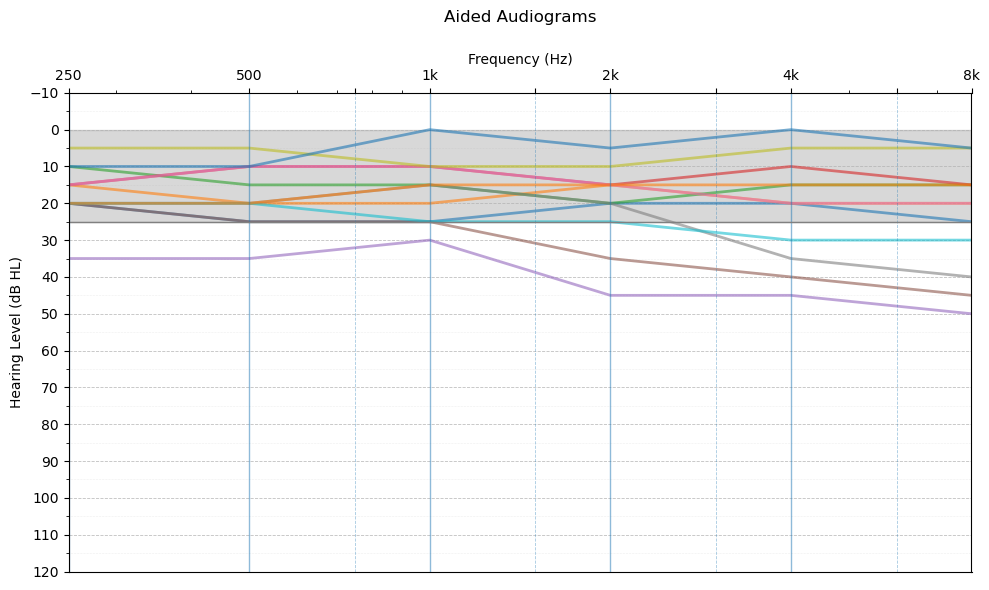

In [4]:
# === Clinical-style audiogram spaghetti plot ===
import numpy as np
import matplotlib.pyplot as plt

# --- Config you might tweak ---
ID_COL = "Aided"
# Octaves + inter-octaves commonly shown on audiograms
OCTAVE_FREQS = [125, 250, 500, 1000, 2000, 4000, 8000]
INTER_OCTAVE_FREQS = [750, 1500, 3000, 6000]  # optional, many clinics show these
ALL_FREQS = OCTAVE_FREQS + INTER_OCTAVE_FREQS

DB_MIN, DB_MAX = -10, 120         # dB HL range displayed
DB_STEP = 10                     # grid spacing
Y_AXIS_ON_RIGHT = False           # set False to put y-axis on left

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Draw all subjects (spaghetti)
for sid, g in df_long.groupby(ID_COL, sort=False):
    ax.plot(g["Frequency_Hz"], g["Threshold"], marker="", linewidth=2, alpha=0.6)

# Audiogram axis styling
ax.set_xscale("log")

# Place frequency ticks at top only
ax.set_xticks(OCTAVE_FREQS + INTER_OCTAVE_FREQS)
# Show labels only for octaves; leave inter-octaves blank or use small labels if you prefer
tick_labels = {125: "125", 250:"250", 500:"500", 1000:"1k", 2000:"2k", 4000:"4k", 8000:"8k"}
ax.set_xticklabels([tick_labels.get(f, "") for f in ax.get_xticks()])
ax.tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=False, labeltop=True)
ax.xaxis.set_label_position('top')
ax.set_xlabel("Frequency (Hz)")

# Invert y so 0 dB HL is at the top like a real audiogram
ax.set_ylim(DB_MAX, DB_MIN)
ax.set_yticks(np.arange(DB_MIN, DB_MAX + 1, DB_STEP))
ax.set_ylabel("Hearing Level (dB HL)")

# Move the y-axis to the right (clinical look)
if Y_AXIS_ON_RIGHT:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
else:
    ax.yaxis.tick_left()
    ax.yaxis.set_label_position("left")

# Gridlines: heavy for octaves / 10 dB, lighter for inter-octaves
ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.6, alpha=0.8)  # 10 dB lines

# Vertical octave lines (slightly bolder)
for f in OCTAVE_FREQS:
    ax.axvline(f, linestyle="-", linewidth=1.0, alpha=0.5)

# Vertical inter-octave lines (lighter)
for f in INTER_OCTAVE_FREQS:
    ax.axvline(f, linestyle="--", linewidth=0.6, alpha=0.4)

# Keep x range tight to [250, 8000]
ax.set_xlim(250, 8000)

# Optional: horizontal minor grid every 5 dB (comment out if too busy)
ax.set_yticks(np.arange(DB_MIN, DB_MAX + 1, 5), minor=True)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4, alpha=0.4)

# --- Normal range shading ---
NORMAL_MAX = 25
ax.axhspan(0, NORMAL_MAX, color="gray", alpha=0.3)  # shade 0–25 dB HL
ax.axhline(NORMAL_MAX, color="gray", linestyle="-", linewidth=1)  # 25 dB line

# Title with a little padding so it clears the top ticks
ax.set_title("Aided Audiograms", pad=22)

plt.tight_layout()
plt.show()

# Cell 5 (optional): Save figure to disk (PNG/SVG)
# out_png = Path("audiogram_spaghetti.png")

# plt.savefig(out_png, dpi=300)
# plt.savefig(out_svg)
# plt.close()

# out_png

<Figure size 900x600 with 0 Axes>

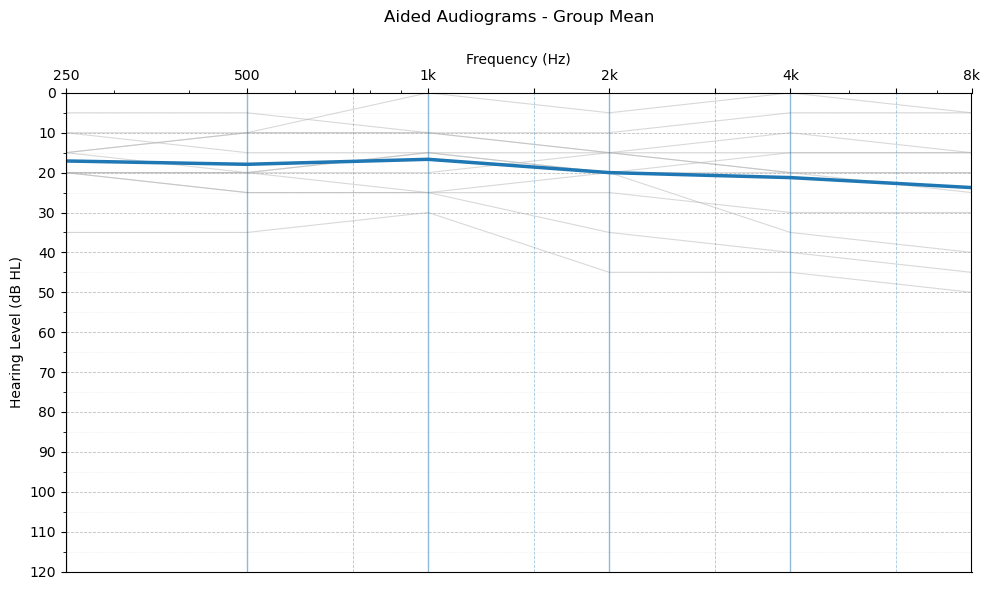

In [7]:
# Cell 4 (optional): Highlight one subject and overlay group mean

# --- Config you might tweak ---
ID_COL = "Aided"
# Octaves + inter-octaves commonly shown on audiograms
OCTAVE_FREQS = [250, 500, 1000, 2000, 4000, 8000]
INTER_OCTAVE_FREQS = [750, 1500, 3000, 6000]  # optional, many clinics show these
ALL_FREQS = OCTAVE_FREQS + INTER_OCTAVE_FREQS

DB_MIN, DB_MAX = 0, 120         # dB HL range displayed
DB_STEP = 10                     # grid spacing
Y_AXIS_ON_RIGHT = False           # set False to put y-axis on left

SUBJECT_TO_HIGHLIGHT = None  # change to any value present in 'Unaided', or set to None to disable

plt.figure(figsize=(9, 6))

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# faint lines for everyone
for sid, g in df_long.groupby(id_col, sort=False):
    plt.plot(g["Frequency_Hz"], g["Threshold"], color="0.7", linewidth=0.8, alpha=0.5)

# highlight one subject in bold
if SUBJECT_TO_HIGHLIGHT is not None:
    g = df_long[df_long[id_col] == SUBJECT_TO_HIGHLIGHT]
    if not g.empty:
        plt.plot(g["Frequency_Hz"], g["Threshold"], marker="o", linewidth=2.5)

# overlay mean across subjects at each frequency
mean_line = (df_long.groupby("Frequency_Hz")["Threshold"]
             .mean()
             .reset_index())
plt.plot(mean_line["Frequency_Hz"], mean_line["Threshold"], linewidth=2.5)







# # Draw all subjects (spaghetti)
# for sid, g in df_long.groupby(ID_COL, sort=False):
#     ax.plot(g["Frequency_Hz"], g["Threshold"], marker="", linewidth=2, alpha=0.6)

# Audiogram axis styling
ax.set_xscale("log")

# Place frequency ticks at top only
ax.set_xticks(OCTAVE_FREQS + INTER_OCTAVE_FREQS)
# Show labels only for octaves; leave inter-octaves blank or use small labels if you prefer
tick_labels = {250:"250", 500:"500", 1000:"1k", 2000:"2k", 4000:"4k", 8000:"8k"}
ax.set_xticklabels([tick_labels.get(f, "") for f in ax.get_xticks()])
ax.tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=False, labeltop=True)
ax.xaxis.set_label_position('top')
ax.set_xlabel("Frequency (Hz)")

# Invert y so 0 dB HL is at the top like a real audiogram
ax.set_ylim(DB_MAX, DB_MIN)
ax.set_yticks(np.arange(DB_MIN, DB_MAX + 1, DB_STEP))
ax.set_ylabel("Hearing Level (dB HL)")

# Move the y-axis to the right (clinical look)
if Y_AXIS_ON_RIGHT:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
else:
    ax.yaxis.tick_left()
    ax.yaxis.set_label_position("left")

# Gridlines: heavy for octaves / 10 dB, lighter for inter-octaves
ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.6, alpha=0.8)  # 10 dB lines

# Vertical octave lines (slightly bolder)
for f in OCTAVE_FREQS:
    ax.axvline(f, linestyle="-", linewidth=1.0, alpha=0.5)

# Vertical inter-octave lines (lighter)
for f in INTER_OCTAVE_FREQS:
    ax.axvline(f, linestyle="--", linewidth=0.6, alpha=0.4)

# Keep x range tight to [250, 8000]
ax.set_xlim(250, 8000)

# Optional: horizontal minor grid every 5 dB (comment out if too busy)
ax.set_yticks(np.arange(DB_MIN, DB_MAX + 1, 5), minor=True)
ax.grid(True, which="minor", axis="y", linestyle=":", linewidth=0.4, alpha=0.4)

# Title with a little padding so it clears the top ticks
ax.set_title("Aided Audiograms - Group Mean", pad=22)

plt.tight_layout()
plt.show()

# Cell 5 (optional): Save figure to disk (PNG/SVG)
# out_png = Path("aided_mean2.png")

# plt.savefig(out_png, dpi=300)
# plt.close()

In [11]:
# Cell 1: Core helpers for marker composition
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle

def _normalized_path_from_builtin(code: str) -> Path:
    """
    Convert a built-in marker code ('o','x','s','^', etc.) into a normalized Path
    in marker space (roughly centered at (0,0), extents ~[-1,1]).
    """
    ms = MarkerStyle(code)
    return ms.get_path()

# def _normalize_path(path: Path, target_half_size: float = 0.5) -> Path:
#     """
#     Scale a Path so that all finite vertices lie within [-target_half_size, target_half_size]
#     in both x and y. Keeps it centered around (0,0).
#     """
#     verts = path.vertices.copy()
#     finite_mask = np.isfinite(verts).all(axis=1)
#     if not np.any(finite_mask):
#         return path  # nothing to do

#     v = verts[finite_mask]
#     max_extent = np.max(np.abs(v))  # max of |x| or |y|

#     if max_extent == 0:
#         return path

#     scale = target_half_size / max_extent
#     verts *= scale
#     return Path(verts, path.codes)

# def _normalize_path_y(path: Path, target_half_size: float = 0.5) -> Path:
#     """
#     Scale a Path so that its vertical extent (|y|) fits within [-target_half_size, target_half_size].
#     Horizontal extent is scaled by the same factor (so aspect ratio is preserved),
#     but we *ignore* wide shapes when deciding the scale.
#     """
#     verts = path.vertices.copy()
#     finite_mask = np.isfinite(verts).all(axis=1)
#     if not np.any(finite_mask):
#         return path

#     v = verts[finite_mask]
#     max_y = np.max(np.abs(v[:, 1]))
#     if max_y == 0:
#         return path

#     scale = target_half_size / max_y
#     verts *= scale
#     return Path(verts, path.codes)

def _arrow_path_marker_space(direction="downright",
                             stem_len=0.9,
                             head_len=0.28,
                             head_angle_deg=28) -> Path:
    """
    Build an NR arrow Path in marker coords. Tail at (0,0), tip in `direction`.
    """
    dirs = {
        "downright": np.array([ 1, -1]) / np.sqrt(2),
        "downleft":  np.array([-1, -1]) / np.sqrt(2),
        "upright":   np.array([ 1,  1]) / np.sqrt(2),
        "upleft":    np.array([-1,  1]) / np.sqrt(2),
        "right":     np.array([ 1,  0]),
        "left":      np.array([-1,  0]),
        "up":        np.array([ 0,  1]),
        "down":      np.array([ 0, -1]),
    }
    d = dirs[direction] / np.linalg.norm(dirs[direction])
    tail = np.array([0.0, 0.0])
    tip  = tail + stem_len * d

    theta = np.deg2rad(head_angle_deg)
    Rpos = np.array([[ np.cos(theta), -np.sin(theta)],
                     [ np.sin(theta),  np.cos(theta)]])
    Rneg = np.array([[ np.cos(-theta), -np.sin(-theta)],
                     [ np.sin(-theta),  np.cos(-theta)]])
    back = -d * head_len
    wing1 = tip + Rpos @ back
    wing2 = tip + Rneg @ back

    verts = np.vstack([
        tail, tip,
        tip, wing1,
        tip, wing2
    ])
    codes = [
        Path.MOVETO, Path.LINETO,   # stem
        Path.MOVETO, Path.LINETO,   # wing 1
        Path.MOVETO, Path.LINETO    # wing 2
    ]
    return Path(verts, codes)

def make_nr_marker(base, *,
                   direction="downright",
                   stem_len=0.9,
                   head_len=0.28,
                   head_angle_deg=28) -> MarkerStyle:
    """
    Compose a base marker (built-in code or Path) with an NR arrow into a single MarkerStyle.
    """
    if isinstance(base, Path):
        base_path = base
    else:
        base_path = _normalized_path_from_builtin(base)

    arr = _arrow_path_marker_space(direction=direction,
                                   stem_len=stem_len,
                                   head_len=head_len,
                                   head_angle_deg=head_angle_deg)

    combo = Path.make_compound_path(base_path, arr)
    # combo_norm = _normalize_path(combo)   # <<< key line: normalize the combo
    return MarkerStyle(combo)

In [22]:
# Cell 2: Audiology markers — built-ins + custom Paths + registry

# --- Custom Paths in marker space (0,0 is the anchor placed at (x,y) in data) ---

# --- Custom Paths in marker space (0,0 is the anchor placed at (x,y) in data) ---

def path_chevron_left():
    # ">" looking (LEFT ear bone unmasked by AU convention)
    a = 1.0
    verts = np.array([[-a, -a],
                      [ a,  0],
                      [-a,  a]])
    codes = [Path.MOVETO, Path.LINETO, Path.LINETO]
    return Path(verts, codes)

def path_chevron_right():
    # "<" looking (RIGHT ear bone unmasked)
    a = 1.0
    verts = np.array([[ a, -a],
                      [-a,  0],
                      [ a,  a]])
    codes = [Path.MOVETO, Path.LINETO, Path.LINETO]
    return Path(verts, codes)

def path_bracket(side="right", height=2.0, depth=1.0) -> Path:
    """
    Bracket marker in *raw* marker coords.

    - Total height ≈ `height` (so default 2.0 matches built-in markers vertically)
    - (0,0) is the INNER midpoint (where the O/X sits).
    - side='right' -> ']' (extends to +x)
      side='left'  -> '[' (extends to -x)
    """
    sgn = 1.0 if side == "right" else -1.0
    h2 = height / 2.0
    x0 = 0.0
    x1 = sgn * depth  # outer edge

    verts = np.array([
        [x0,  +h2], [x1,  +h2],   # top stroke outward
        [x1,  +h2], [x1,  -h2],   # vertical
        [x1,  -h2], [x0,  -h2],   # bottom stroke inward
    ], float)
    codes = [
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
    ]
    return Path(verts, codes)

# Built-ins we’ll re-use for air & masked air
PATH_O      = _normalized_path_from_builtin("o")   # open circle
PATH_X      = _normalized_path_from_builtin("x")   # X
PATH_SQUARE = _normalized_path_from_builtin("s")   # square
PATH_TRI    = _normalized_path_from_builtin("^")   # triangle up

# Custom bone & bracket shapes
PATH_CHEV_L  = path_chevron_left()
PATH_CHEV_R  = path_chevron_right()
PATH_BRACK_R = path_bracket(side="right")
PATH_BRACK_L = path_bracket(side="left")

# --- Marker registry ---
# Names you can call: 'o', 'x', 'square', 'triangle', 'chev_left', 'chev_right', 'brack_left', 'brack_right'
MARKER_REGISTRY = {
    "o":           MarkerStyle(PATH_O),
    "x":           MarkerStyle(PATH_X),
    "square":      MarkerStyle(PATH_SQUARE),
    "triangle":    MarkerStyle(PATH_TRI),
    "chev_left":   MarkerStyle(PATH_CHEV_L),
    "chev_right":  MarkerStyle(PATH_CHEV_R),
    "brack_left":  MarkerStyle(PATH_BRACK_L),
    "brack_right": MarkerStyle(PATH_BRACK_R),
}

def get_marker(name: str) -> MarkerStyle:
    """
    Fetch a MarkerStyle by name from the registry.
    """
    if name not in MARKER_REGISTRY:
        raise KeyError(f"Unknown marker '{name}'. Options: {list(MARKER_REGISTRY)}")
    return MARKER_REGISTRY[name]

def get_nr_marker(name: str, *, ear: str = "right",
                  direction_map=None, **arrow_kwargs) -> MarkerStyle:
    """
    Return a MarkerStyle with an NR arrow baked in.
    ear='right' -> default 'downright'; ear='left' -> 'downleft' (override via direction_map).
    """
    base_marker = get_marker(name)
    base_path = base_marker.get_path()  # already normalized

    dir_default = {"right": "downright", "left": "downleft"}
    if direction_map is None:
        direction_map = dir_default
    direction = direction_map.get(ear.lower(), "downright")

    return make_nr_marker(base_path, direction=direction, **arrow_kwargs)

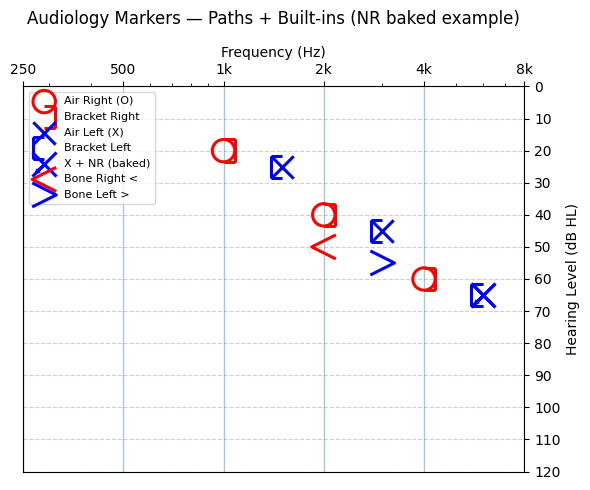

In [23]:
# Cell 3: Demo / sanity-check

fig, ax = plt.subplots(figsize=(6, 5))

x_vals = [1000, 2000, 4000]
y_vals = [20, 40, 60]

# Right ear (red): O + right bracket + NR
ax.scatter(x_vals, y_vals, s=260,
           marker=get_marker("o"),
           facecolors="none", edgecolors="red", linewidths=2.2, zorder=3, label="Air Right (O)")
ax.scatter(x_vals, y_vals, s=260,
           marker=get_marker("brack_right"),
           facecolors="none", edgecolors="red", linewidths=2.2, zorder=2, label="Bracket Right")

# Left ear (blue): X + left bracket + NR baked marker for the middle point
ax.scatter([1500, 3000, 6000], [25, 45, 65], s=260,
           marker=get_marker("x"),
           color="blue", linewidths=2.2, zorder=3, label="Air Left (X)")
ax.scatter([1500, 3000, 6000], [25, 45, 65], s=260,
           marker=get_marker("brack_left"),
           facecolors="none", edgecolors="blue", linewidths=2.2, zorder=2, label="Bracket Left")

# Bake NR into the base marker (left ear example at 6000 Hz)
ax.scatter([6000], [65], s=300,
           marker=get_nr_marker("x", ear="left"),
           color="blue", linewidths=2.2, zorder=4, label="X + NR (baked)")

# Bone: right = "<", left = ">"
ax.scatter([2000], [50], s=300,
           marker=get_marker("chev_right"),
           facecolors="none", edgecolors="red", linewidths=2.2, zorder=3, label="Bone Right <")
ax.scatter([3000], [55], s=300,
           marker=get_marker("chev_left"),
           facecolors="none", edgecolors="blue", linewidths=2.2, zorder=3, label="Bone Left >")

# Clinical-ish axes (log x, inverted y)
ax.set_xscale("log")
ax.set_xticks([250, 500, 1000, 2000, 4000, 8000])
ax.set_xticklabels(["250", "500", "1k", "2k", "4k", "8k"])
ax.tick_params(axis='x', which='both', bottom=False, top=True, labelbottom=False, labeltop=True)
ax.xaxis.set_label_position('top')
ax.set_xlabel("Frequency (Hz)")

ax.set_ylim(120, 0)
ax.set_yticks(np.arange(0, 121, 10))
ax.set_ylabel("Hearing Level (dB HL)")
ax.yaxis.tick_right(); ax.yaxis.set_label_position("right")

# Grid + bracket kiss check
for f in [250, 500, 1000, 2000, 4000, 8000]:
    ax.axvline(f, linewidth=1, alpha=0.4)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

ax.set_title("Audiology Markers — Paths + Built-ins (NR baked example)", pad=16)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

2nd Take Markers for Audiogram Plots

In [32]:
# Air thresholds

import numpy as np
import matplotlib.pyplot as plt

def plot_air_thresholds(
    ax,
    freqs,
    thrs,
    *,
    ear: str,
    masked: bool = False,
    nr: np.ndarray | None = None,
    color: str | None = None,
    size: float = 60,
    **scatter_kwargs,
):
    """
    Plot air-conduction thresholds for one ear.

    Parameters
    ----------
    ax : matplotlib Axes
    freqs : array-like
        Frequencies in Hz.
    thrs : array-like
        Thresholds in dB HL.
    ear : {'right', 'left'}
    masked : bool
        Whether these are masked thresholds (True) or unmasked (False).
    nr : array-like of bool, optional
        Same length as freqs; True where 'no response' arrow should be drawn.
    color : str, optional
        Matplotlib color. Defaults: 'red' for right, 'blue' for left.
    size : float
        Marker size for scatter.
    scatter_kwargs :
        Passed through to ax.scatter.
    """
    ear = ear.lower()
    freqs = np.asarray(freqs)
    thrs = np.asarray(thrs)

    if color is None:
        color = "red" if ear == "right" else "blue"

    if masked:
        marker = "^" if ear == "right" else "s"
    else:
        marker = "o" if ear == "right" else "x"

    pts = ax.scatter(
        freqs,
        thrs,
        s=size,
        marker=marker,
        facecolors="none" if marker in ("o", "s", "^") else color,
        edgecolors=color,
        linewidths=2,
        zorder=3,
        **scatter_kwargs,
    )

    if nr is not None:
        draw_nr_arrows(ax, freqs, thrs, nr, color=color, ear=ear)

    return pts

In [33]:
# Bone Thresholds

def plot_bone_thresholds(
    ax,
    freqs,
    thrs,
    *,
    ear: str,
    masked: bool = False,
    nr: np.ndarray | None = None,
    color: str | None = None,
    size: float = 60,
    offset_frac: float = 0.03,
    **scatter_kwargs,
):
    """
    Plot bone-conduction thresholds for one ear.

    Uses small x-axis fudge to visually offset symbols from the midline.

    - Unmasked: '<' (right), '>' (left)
    - Masked:   '[' (right), ']' (left) using custom markers or text later.

    Parameters
    ----------
    offset_frac : float
        Fractional shift in frequency: e.g. 0.03 means 3% shift.
        Right ear shifts to higher freq, left to lower.
    """
    ear = ear.lower()
    freqs = np.asarray(freqs)
    thrs = np.asarray(thrs)

    if color is None:
        color = "red" if ear == "right" else "blue"

    # Apply small frequency shift for visual separation
    sgn = +1 if ear == "right" else -1
    freqs_plot = freqs * (1.0 + sgn * offset_frac)

    if not masked:
        # Built-in chevrons
        marker = "<" if ear == "right" else ">"
    else:
        # For now, use simple bracket-as-text-ish markers; we can swap
        # in a proper Path-based marker later without changing this API.
        marker = "P"  # placeholder; we'll override via custom MarkerStyle later
        # But for a quick-and-dirty version, you can just use '|' or another symbol.

    pts = ax.scatter(
        freqs_plot,
        thrs,
        s=size,
        marker=marker if not masked else "<",  # TEMP: re-use '<' as stand-in
        facecolors="none",
        edgecolors=color,
        linewidths=2,
        zorder=3,
        **scatter_kwargs,
    )

    if nr is not None:
        draw_nr_arrows(ax, freqs_plot, thrs, nr, color=color, ear=ear)

    return pts

In [44]:
# NR Arrows

def draw_nr_arrows(
    ax,
    freqs,
    thrs,
    nr_flags,
    *,
    ear: str,
    color: str = "black",
    dx_frac: float = 0.1,   # how far arrow moves horizontally (fraction of freq)
    dy_db: float = 5.0,     # how far arrow moves downward (in dB)
    **arrowprops_overrides,
):
    """
    Draw diagonal NR arrows for audiogram points.

    Right ear:  arrow goes down-left (45°)
    Left ear:   arrow goes down-right (45°)

    Parameters
    ----------
    freqs, thrs : array-like
        Coordinates of the symbols.
    nr_flags : array-like of bool
        True where NR arrow should be drawn.
    ear : {'right', 'left'}
        Determines arrow direction.
    dx_frac : float
        Horizontal offset as a fraction of frequency (log scale okay).
    dy_db : float
        Vertical length of arrow in dB HL (positive is 'down' because y-axis is inverted).
    """
    freqs = np.asarray(freqs)
    thrs = np.asarray(thrs)
    nr_flags = np.asarray(nr_flags, dtype=bool)
    ear = ear.lower()

    # Right ear arrow goes down-left   → x - dx, y + dy
    # Left ear arrow goes down-right   → x + dx, y + dy
    sgn = -1 if ear == "right" else +1

    default_props = dict(
        arrowstyle="-|>",
        color=color,
        linewidth=2.2,
        shrinkA=0,
        shrinkB=0,
    )
    default_props.update(arrowprops_overrides)

    for x, y, is_nr in zip(freqs, thrs, nr_flags):
        if not is_nr or np.isnan(y):
            continue

        dx = x * dx_frac
        dy = dy_db  # downward on inverted axis

        ax.annotate(
            "",
            xy=(x + sgn * dx, y + dy),
            xytext=(x, y),
            arrowprops=default_props,
            zorder=5,
        )

/var/folders/7t/n5kfjhrj61q7b7r6q4t0tzhw0000gp/T/ipykernel_53965/1586973963.py:52: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  pts = ax.scatter(


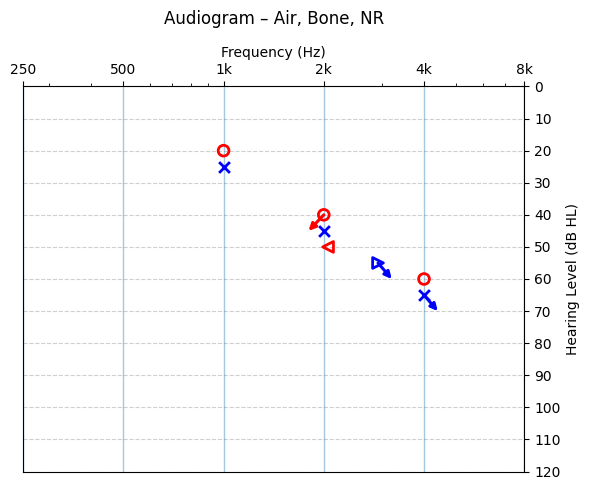

In [45]:
# Demo/Iteration

fig, ax = plt.subplots(figsize=(6, 5))

freqs = [1000, 2000, 4000]
thrs_r_air = [20, 40, 60]
thrs_l_air = [25, 45, 65]

nr_right = [False, True, False]  # example: NR at 2000 right
nr_left  = [False, False, True]  # example: NR at 4000 left

# Right ear air, unmasked
plot_air_thresholds(ax, freqs, thrs_r_air, ear="right", masked=False, nr=nr_right)

# Left ear air, unmasked
plot_air_thresholds(ax, freqs, thrs_l_air, ear="left", masked=False, nr=nr_left)

# Right ear bone, unmasked at a couple of points
plot_bone_thresholds(ax, [2000], [50], ear="right", masked=False, nr=[False])

# Left ear bone, unmasked
plot_bone_thresholds(ax, [3000], [55], ear="left", masked=False, nr=[True])

# Then your usual audiogram axes styling...
ax.set_xscale("log")
ax.set_xticks([250, 500, 1000, 2000, 4000, 8000])
ax.set_xticklabels(["250", "500", "1k", "2k", "4k", "8k"])
ax.tick_params(axis='x', which='both', bottom=False, top=True,
               labelbottom=False, labeltop=True)
ax.xaxis.set_label_position('top')
ax.set_xlabel("Frequency (Hz)")

ax.set_ylim(120, 0)
ax.set_yticks(np.arange(0, 121, 10))
ax.set_ylabel("Hearing Level (dB HL)")
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

for f in [250, 500, 1000, 2000, 4000, 8000]:
    ax.axvline(f, linewidth=1, alpha=0.4)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

ax.set_title("Audiogram – Air, Bone, NR", pad=16)
plt.tight_layout()
plt.show()

1. Core: SymbolPath + drawing helper

In [87]:
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch


@dataclass
class SymbolPath:
    """
    Geometry for a symbol in LOCAL coordinates.

    - verts: (N, 2) array in "symbol space"
    - codes: (N,) Path codes (MOVETO, LINETO, etc.)
    - anchor: where local (0,0) should sit conceptually (e.g., where the air symbol would be).
    """
    verts: np.ndarray
    codes: np.ndarray
    anchor: Tuple[float, float] = (0.0, 0.0)


def draw_symbol(
    ax,
    symbol: SymbolPath,
    x: float,
    y: float,
    *,
    color: str = "black",
    size_db: float = 10.0,
    x_frac: float = 0.03,
    linewidth: float = 2.0,
    zorder: int = 4,
):
    """
    Draw a SymbolPath on an audiogram at data coords (x, y).

    - x-axis is log frequency; we scale horizontally by a FRACTION of x (x_frac),
      so symbol width is roughly constant in screen space.
    - y-axis is in dB HL; we scale vertical size in dB using size_db.

    LOCAL COORDS:
      - symbol.verts are typically in [-1, 1] range.
      - height ≈ 2 units in local space -> size_db tall in dB.
      - width ≈ 2 units -> about 2 * x * x_frac in Hz (on log scale this looks
        like a constant offset in octaves).
    """
    verts_local = symbol.verts - np.array(symbol.anchor, dtype=float)

    # Scale factors in data units
    sx = x * x_frac              # fractional frequency shift (log axis friendly)
    sy = size_db / 2.0           # local y ∈ [-1,1] => total height = size_db

    xs = x + verts_local[:, 0] * sx
    ys = y + verts_local[:, 1] * sy

    path = Path(np.column_stack([xs, ys]), symbol.codes)
    patch = PathPatch(
        path,
        fill=False,
        edgecolor=color,
        linewidth=linewidth,
        zorder=zorder,
    )
    ax.add_patch(patch)
    return patch
    

Config Dataclasses

In [88]:
from dataclasses import dataclass

@dataclass(frozen=True)
class BoneChevronConfig:
    tip: float = 0.65        # how far the chevron vertex sits outside the anchor
    gap: float = 0.10        # how far the arms stop short of the anchor (never cross x=0)
    half_height: float = 1.0 # in local symbol coords (y from -half_height to +half_height)

@dataclass(frozen=True)
class BoneBracketConfig:
    half_height: float = 1.0 # in local coords
    depth: float = 0.80      # how far bracket extends outward from the open side

@dataclass(frozen=True)
class SymbolSizingConfig:
    air_marker_size: float = 80     # matplotlib scatter s (points^2)
    bone_size_db: float = 12.0      # vertical height in dB for custom bone symbols
    bone_x_frac: float = 0.04       # horizontal scaling as a fraction of frequency (log-friendly)
    linewidth: float = 2.0

@dataclass(frozen=True)
class NRArrowConfig:
    length_db: float = 15.0         # arrow length downward in dB HL
    x_frac: float = 0.03            # diagonal component as a fraction of frequency
    head_style: str = "-|>"         # matplotlib arrowstyle
    linewidth: float = 2.2

@dataclass(frozen=True)
class AudiogramRenderConfig:
    chevron: BoneChevronConfig = BoneChevronConfig()
    bracket: BoneBracketConfig = BoneBracketConfig()
    sizing: SymbolSizingConfig = SymbolSizingConfig()
    nr: NRArrowConfig = NRArrowConfig()

Bone Symbols tied to config dataclasses

In [89]:
import numpy as np
from matplotlib.path import Path

# assumes you already have SymbolPath dataclass defined from earlier

def symbol_bone_unmasked_right(cfg: AudiogramRenderConfig) -> SymbolPath:
    """
    Right ear unmasked bone: '<' entirely on the LEFT side of anchor (x <= -gap),
    with vertex at x=-tip. Arms do not cross x=0.
    """
    tip = cfg.chevron.tip
    gap = cfg.chevron.gap
    hh  = cfg.chevron.half_height

    x_tip = -tip
    x_arm = -gap

    verts = np.array([[x_arm, -hh],
                      [x_tip,  0.0],
                      [x_arm, +hh]], float)
    codes = np.array([Path.MOVETO, Path.LINETO, Path.LINETO], int)
    return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))

def symbol_bone_unmasked_left(cfg: AudiogramRenderConfig) -> SymbolPath:
    """
    Left ear unmasked bone: '>' entirely on the RIGHT side of anchor (x >= +gap),
    with vertex at x=+tip.
    """
    tip = cfg.chevron.tip
    gap = cfg.chevron.gap
    hh  = cfg.chevron.half_height

    x_tip = +tip
    x_arm = +gap

    verts = np.array([[x_arm, -hh],
                      [x_tip,  0.0],
                      [x_arm, +hh]], float)
    codes = np.array([Path.MOVETO, Path.LINETO, Path.LINETO], int)
    return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))

def symbol_bone_masked_right(cfg: AudiogramRenderConfig) -> SymbolPath:
    """
    Right ear masked bone: '[' open to the RIGHT; bracket extends to negative x.
    Anchor at open side midpoint (0,0).
    """
    hh = cfg.bracket.half_height
    d  = cfg.bracket.depth
    g  = cfg.chevron.gap  # universal clearance gap

    x_open = -g
    x_bar  = -(g + d)

    verts = np.array([
        [x_open, +hh], [x_bar, +hh],
        [x_bar,  +hh], [x_bar, -hh],
        [x_bar,  -hh], [x_open, -hh],
    ], float)
    
    codes = np.array([
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
        Path.MOVETO, Path.LINETO,
    ], int)
    return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))

def symbol_bone_masked_left(cfg: AudiogramRenderConfig) -> SymbolPath:
    """
    Left ear masked bone: ']' open to the LEFT; bracket extends to positive x.
    """
    base = symbol_bone_masked_right(cfg)
    verts = base.verts.copy()
    verts[:, 0] *= -1.0
    return SymbolPath(verts=verts, codes=base.codes, anchor=base.anchor)

Convenience Registry so plot code stays clean

In [90]:
def get_bone_symbol(cfg: AudiogramRenderConfig, *, ear: str, masked: bool) -> SymbolPath:
    ear = ear.lower()
    if masked:
        return symbol_bone_masked_right(cfg) if ear == "right" else symbol_bone_masked_left(cfg)
    return symbol_bone_unmasked_right(cfg) if ear == "right" else symbol_bone_unmasked_left(cfg)

In [86]:
# def symbol_bone_unmasked_right(*, tip: float = 0.65, depth: float = -0.1, half_height: float = 1.0) -> SymbolPath:
#     """
#     Right ear unmasked bone: '<' that WRAPS the anchor.
#     Anchor is at (0,0) (air symbol location).
#     The chevron vertex (tip) is shifted to x = -tip (outside, to the left).
#     The arms extend to x = +depth (to the right).
#     """
#     x_tip = -tip
#     x_arm = +depth

#     verts = np.array([
#         [x_arm, -half_height],
#         [x_tip,  0.0],
#         [x_arm, +half_height],
#     ], float)
#     codes = np.array([Path.MOVETO, Path.LINETO, Path.LINETO], int)
#     return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))


# def symbol_bone_unmasked_left(*, tip: float = 0.45, depth: float = 0.95, half_height: float = 1.0) -> SymbolPath:
#     """
#     Left ear unmasked bone: '>' that WRAPS the anchor.
#     The chevron vertex is shifted to x = +tip (outside, to the right).
#     Arms extend to x = -depth.
#     """
#     x_tip = +tip
#     x_arm = -depth

#     verts = np.array([
#         [x_arm, -half_height],
#         [x_tip,  0.0],
#         [x_arm, +half_height],
#     ], float)
#     codes = np.array([Path.MOVETO, Path.LINETO, Path.LINETO], int)
#     return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))

In [ ]:
# def symbol_bone_masked_right() -> SymbolPath:
#     """
#     Right ear bone, masked: '[' (open to the right).
#     Anchor (0,0) is at the OPEN side midpoint (where the air symbol would be).
#     Bracket extends to NEGATIVE x.
#     """
#     h = 1.0   # half-height
#     w = 0.8   # how far bracket extends left from open side

#     verts = np.array([
#         [0.0,  h], [-w,  h],   # top stroke from open side to vertical bar
#         [-w,  h], [-w, -h],   # vertical stroke
#         [-w, -h], [0.0, -h],  # bottom stroke back to open side
#     ], dtype=float)

#     codes = np.array(
#         [
#             Path.MOVETO, Path.LINETO,
#             Path.MOVETO, Path.LINETO,
#             Path.MOVETO, Path.LINETO,
#         ],
#         dtype=int,
#     )
#     return SymbolPath(verts=verts, codes=codes, anchor=(0.0, 0.0))


# def symbol_bone_masked_left() -> SymbolPath:
#     """
#     Left ear bone, masked: ']' (open to the left).
#     Mirror of the right masked bracket.
#     Open side at x = 0, bracket extends to POSITIVE x.
#     """
#     base = symbol_bone_masked_right()
#     verts = base.verts.copy()
#     verts[:, 0] *= -1.0   # mirror horizontally
#     return SymbolPath(verts=verts, codes=base.codes, anchor=(0.0, 0.0))

Demo: bone symbols wrapping air

Here’s a minimal demo that uses:
	•	Built-in markers for air (o / x)
	•	The custom bone symbols drawn via draw_symbol

The key knobs to tweak visually:
	•	size_db (vertical “height” of the symbols)
	•	x_frac (how far left/right the symbol extends in frequency space)



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Create a config (your preferred values)
cfg = AudiogramRenderConfig(
    chevron=BoneChevronConfig(tip=1, gap=0.4, half_height=0.6),
    bracket=BoneBracketConfig(half_height=1.0, depth=0.80),
    sizing=SymbolSizingConfig(
        air_marker_size=80,
        bone_size_db=12.0,
        bone_x_frac=0.06,   # start modest; 0.15 is huge
        linewidth=2.0
    )
)

# ---- Demo: plug into an audiogram-like axis ----
fig, ax = plt.subplots(figsize=(6, 5))

freqs = [1000, 2000, 4000]
thrs_air_r = [20, 40, 60]
thrs_air_l = [25, 45, 65]

# Plot air thresholds with built-ins
ax.scatter(freqs, thrs_air_r, s=cfg.sizing.air_marker_size, marker="o",
           facecolors="none", edgecolors="red", linewidths=cfg.sizing.linewidth,
           zorder=3, label="Air Right (O)")
ax.scatter(freqs, thrs_air_l, s=cfg.sizing.air_marker_size, marker="x",
           color="blue", linewidths=cfg.sizing.linewidth,
           zorder=3, label="Air Left (X)")

# 2) Build bone symbols USING cfg
bone_r_sym     = symbol_bone_unmasked_right(cfg)
bone_l_sym     = symbol_bone_unmasked_left(cfg)
bone_r_masked  = symbol_bone_masked_right(cfg)
bone_l_masked  = symbol_bone_masked_left(cfg)

# 3) Draw bone symbols (suggest: bone under air, so zorder=2)
draw_symbol(ax, bone_r_sym, x=2000, y=40,
            color="red",
            size_db=cfg.sizing.bone_size_db,
            x_frac=cfg.sizing.bone_x_frac,
            linewidth=cfg.sizing.linewidth,
            zorder=2)

draw_symbol(ax, bone_l_sym, x=3000, y=55,
            color="blue",
            size_db=cfg.sizing.bone_size_db,
            x_frac=cfg.sizing.bone_x_frac,
            linewidth=cfg.sizing.linewidth,
            zorder=2)

draw_symbol(ax, bone_r_masked, x=1000, y=20,
            color="red",
            size_db=cfg.sizing.bone_size_db,
            x_frac=cfg.sizing.bone_x_frac,
            linewidth=cfg.sizing.linewidth,
            zorder=2)

draw_symbol(ax, bone_l_masked, x=4000, y=60,
            color="blue",
            size_db=cfg.sizing.bone_size_db,
            x_frac=cfg.sizing.bone_x_frac,
            linewidth=cfg.sizing.linewidth,
            zorder=2)

# Clinical-ish axes
ax.set_xscale("log")
ax.set_xticks([250, 500, 1000, 2000, 4000, 8000])
ax.set_xticklabels(["250", "500", "1k", "2k", "4k", "8k"])
ax.tick_params(axis='x', which='both', bottom=False, top=True,
               labelbottom=False, labeltop=True)
ax.xaxis.set_label_position('top')
ax.set_xlabel("Frequency (Hz)")

ax.set_ylim(120, 0)
ax.set_yticks(np.arange(0, 121, 10))
ax.set_ylabel("Hearing Level (dB HL)")
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

for f in [250, 500, 1000, 2000, 4000, 8000]:
    ax.axvline(f, linewidth=1, alpha=0.4)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

ax.set_title("Custom ANSI-style Bone Symbols (gap applied)", pad=16)
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

NameError: name 'AudiogramRenderConfig' is not defined